In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, GRU

%matplotlib inline

In [5]:
# df = pd.read_csv('btc_max_ohlc_yfinance.csv')
df = pd.read_csv('btc_change_rate.csv')

df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])

df.sort_values("date", axis=0, ascending=True, inplace=True)

# 篩選2021-07-01之後的資料
df = df[df['date'] >= '2021-07-01'].copy()

df = df.set_index('date')
print(df)
# df.drop(['unix', 'symbol', 'tradecount'], axis=1, inplace=True)

            change_rate
date                   
2021-07-01    -4.178182
2021-07-02     1.035617
2021-07-03     2.404782
2021-07-04     1.794907
2021-07-05    -4.359837
...                 ...
2026-05-08     0.221399
2026-05-09     0.594386
2026-05-10     1.826454
2026-05-11    -0.500067
2026-05-12    -2.169012

[1777 rows x 1 columns]


In [16]:
# increasing rate data

data_returns = df.iloc[:, 0]

windows = []
target = []
length = 10

for i in range(len(data_returns) - length):
    x = data_returns[i : i+length]
    y = data_returns[i+length]
    windows.append(x)
    target.append(y)

windows = np.array(windows)
target = np.array(target).reshape(-1, 1)

sc = StandardScaler()
windows_scaled = sc.fit_transform(windows)
target_scaled = sc.fit_transform(target)

windows_scaled = windows_scaled.reshape((len(windows_scaled), length, 1))

# 4. 切分 80% 訓練集與 20% 測試集
num_train = int(0.80 * windows_scaled.shape[0])

X_train = windows_scaled[:num_train, :, :]
X_test = windows_scaled[num_train:, :, :]
y_train = target_scaled[:num_train, :]
y_test = target_scaled[num_train:, :]

print(f"X_train shape: {X_train.shape}") # 預期輸出: (樣本數, 10, 1)
print(f"y_train shape: {y_train.shape}") # 預期輸出: (樣本數, 1)

X_train shape: (1413, 10, 1)
y_train shape: (1413, 1)


/tmp/ipykernel_558/3754669541.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = data_returns[i+length]


In [ ]:
# price data

# 取close欄位，index = 3
data = df.iloc[:, 3]
windows = []
target = []
length = 10

# 建立長度為 10 的window slide
for i in range(len(data)-length):
    x = data[i:i+length]
    y = data[i+length]
    windows.append(x)
    target.append(y)

windows = np.array(windows)
target = np.array(target)
target = target.reshape(-1, 1)

# 正規化資料到 0~1 之間
sc = MinMaxScaler()
windows_scaled = sc.fit_transform(windows)
target_scaled = sc.fit_transform(target)

# Reshape 符合 GRU 輸入格式 (batch_size, window_size, input_dim)
windows_scaled = windows_scaled.reshape((len(windows_scaled), length, 1))

# 切分 80% 訓練集與 20% 測試集
num_train = int(0.80 * windows_scaled.shape[0])

X_train = windows_scaled[:num_train, :, :]
X_test = windows_scaled[num_train:, :, :]
y_train = target_scaled[:num_train, :]
y_test = target_scaled[num_train:, :]

/tmp/ipykernel_11555/1208711784.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = data[i+length]


In [17]:
# 定義建立模型的函數
def build_gru_model(input_data, output_size, neurons, activ_func, dropout, loss, optimizer):
    model = Sequential()
    model.add(GRU(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))
    model.compile(loss=loss, optimizer=optimizer)
    return model

# 設定超參數
gru_neurons = 100
epochs = 20
batch_size = 32
loss = 'mse'
dropout = 0.2
optimizer = 'adam'
activ_func = 'linear'

# 建立並訓練模型 (切分 10% 做驗證集)
model = build_gru_model(X_train, output_size=1, neurons=gru_neurons, activ_func=activ_func,
                        dropout=dropout, loss=loss, optimizer=optimizer)

out = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 1.1255 - val_loss: 0.9209
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1177 - val_loss: 0.9181
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1123 - val_loss: 0.9197
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1137 - val_loss: 0.9215
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1128 - val_loss: 0.9196
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1197 - val_loss: 0.9184
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1155 - val_loss: 0.9178
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1097 - val_loss: 0.9167
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1133 - val_loss: 0.9200
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1120 - val_loss: 0.9192
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1109 - val_loss: 0.9167
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1149 - val_l

In [18]:
# 進行預測
pred = model.predict(X_test)

# 將預測結果與實際結果逆轉換回真實價格區間
pred_transformed = sc.inverse_transform(pred)
y_test_transformed = sc.inverse_transform(y_test)

# 計算各項誤差指標 (MSE, RMSE, MAPE, MAE)
mse = mean_squared_error(pred, y_test)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
mape = mean_absolute_percentage_error(pred, y_test)
print("MAPE:", mape)
mae = mean_absolute_error(pred, y_test)
print("MAE:", mae)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
MSE: 0.6414598772672147
RMSE: 0.8009119035619428
MAPE: 31.369700337293544
MAE: 0.5642983004836678


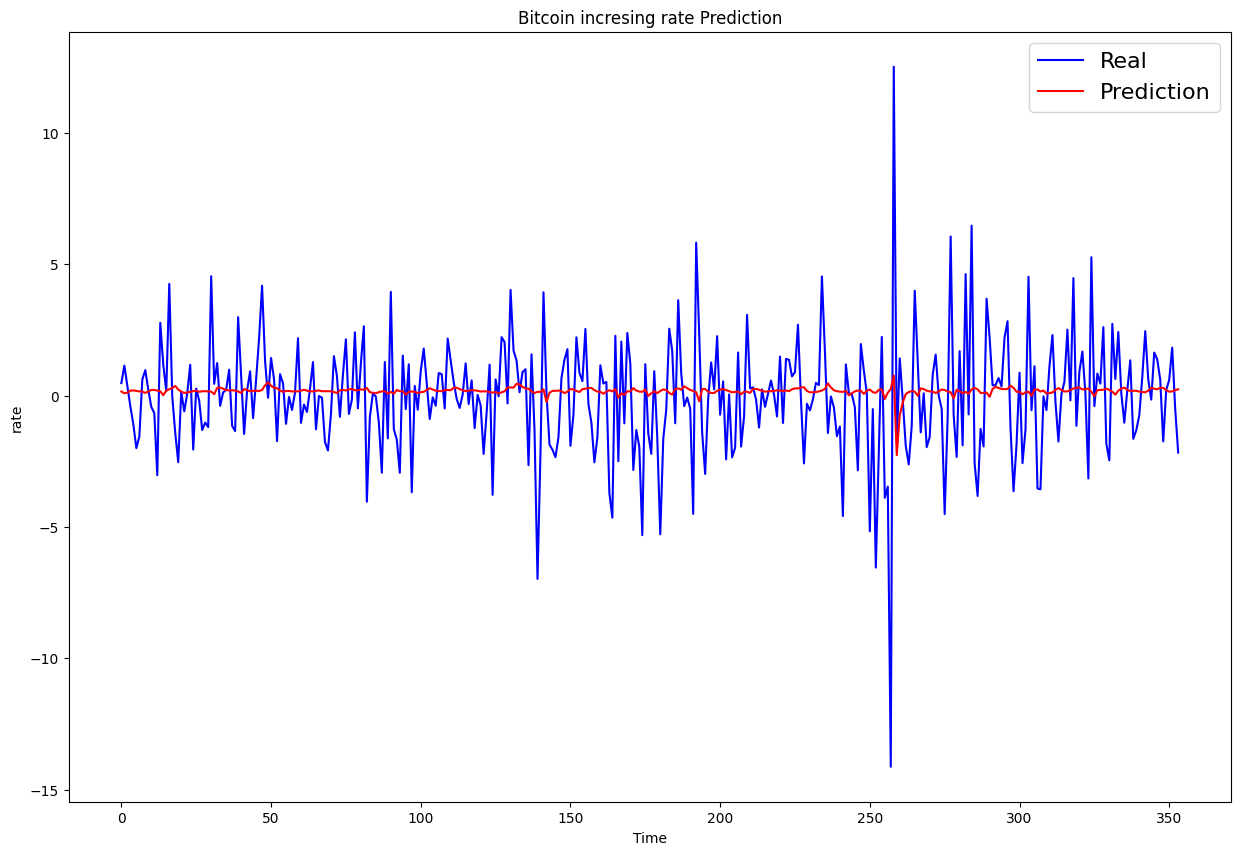

In [19]:
# increasing rate and prediction rate plot
plt.figure(figsize=(15,10))
plt.plot(y_test_transformed, color='blue', label='Real')
plt.plot(pred_transformed, color='red', label='Prediction')
plt.title('Bitcoin incresing rate Prediction')
plt.ylabel('rate')
plt.xlabel('Time')
plt.legend(loc='best', fontsize=16)
plt.show()

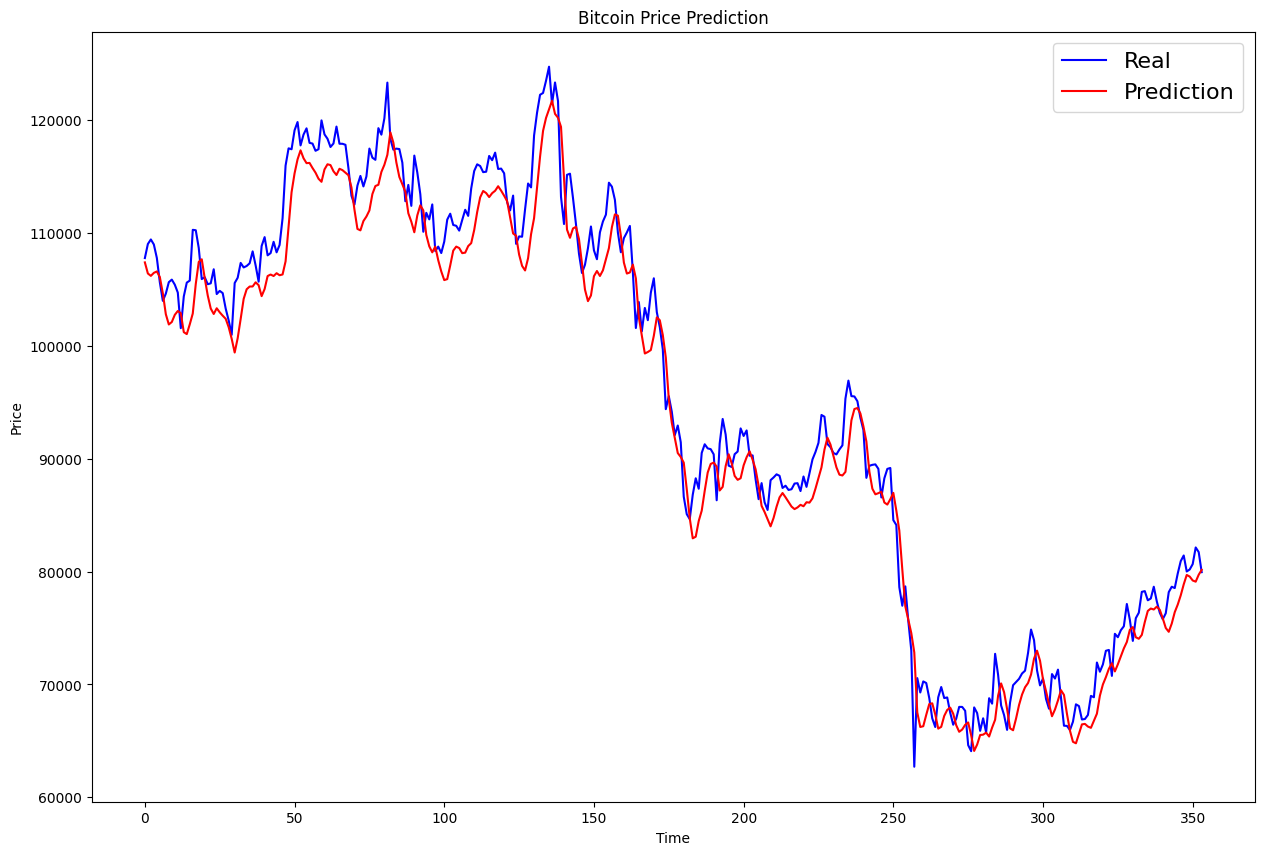

In [ ]:
# 繪製真實價格與預測價格的走勢圖
plt.figure(figsize=(15,10))
plt.plot(y_test_transformed, color='blue', label='Real')
plt.plot(pred_transformed, color='red', label='Prediction')
plt.title('Bitcoin Price Prediction')
plt.ylabel('Price')
plt.xlabel('Time')
plt.legend(loc='best', fontsize=16)
plt.show()